Demo File for Visbility Graph

Source 3D Print: https://www.thingiverse.com/thing:6407541


In [1]:
!pip install pandas numpy matplotlib shapely


[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from shapely.geometry import Polygon, LineString
import math
import heapq
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [3]:
mpl.rcParams.update({
    # Fonts
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    # Figure / axes
    "figure.dpi": 120,
    "figure.figsize": (7, 7),
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.linewidth": 0.8,

    # Lines
    "lines.linewidth": 1.0,
    "lines.markersize": 5,

    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    # Legend
    "legend.fontsize": 9,
    "legend.frameon": False,

    # Grid (subtle)
    "axes.grid": False,  # we'll turn grid on per-plot with light alpha
})

In [4]:
csv_path = "CSV_Data/Simulation_Data_VG_V1.0_13.11.25.csv"

In [5]:
df = pd.read_csv(csv_path, sep=";")   # semicolon-delimited
df.columns = [c.lower().strip() for c in df.columns]

df["x"] = pd.to_numeric(df["x"], errors="coerce")
df["y"] = pd.to_numeric(df["y"], errors="coerce")
df = df.dropna(subset=["x","y"])

# ------------------------------------------
# CONVERT UNITS: cm → mm
# ------------------------------------------
UNIT_SCALE = 10.0  # 1 cm = 10 mm
df["x"] = df["x"] * UNIT_SCALE
df["y"] = df["y"] * UNIT_SCALE

# polygons: id -> list of (x, y) points (we'll talk about order next)
polygons = {
    pid: [(float(x), float(y)) for x, y in g[["x","y"]].to_numpy()]
    for pid, g in df.groupby("id")
    if len(g) >= 3
}

# special points we may want later (start/goal/waypoints)
special_points = {
    row["type"].lower(): (float(row["x"]), float(row["y"]))
    for _, row in df[df["type"].str.lower().isin(["start","goal","waypoint"])].iterrows()
}

print("polygons keys:", list(polygons.keys()))
print("special points:", special_points)

# ---------------------------------------------------------------------------
# Helpers for check CCW or CW
def signed_area(ring):
    # shoelace formula; positive => CCW, negative => CW
    a = 0.0
    for (x1,y1),(x2,y2) in zip(ring, ring[1:]+ring[:1]):
        a += x1*y2 - x2*y1
    return 0.5 * a

def is_ccw(ring):
    return signed_area(ring) > 0

def ensure_ccw(ring):
    return ring if is_ccw(ring) else list(reversed(ring))

# Check all polygons
flipped = []
polygons_ccw = {}

for pid, pts in polygons.items():
    if is_ccw(pts):
        polygons_ccw[pid] = pts
    else:
        polygons_ccw[pid] = list(reversed(pts))
        flipped.append(pid)

# Print summary
if len(flipped) == 0:
    print("All polygons are already counter-clockwise (CCW).")
else:
    print("The following polygons were clockwise (CW) and have been flipped to CCW:")
    for pid in flipped:
        print(f"  - {pid}")

# Optional: show signed areas for verification
for pid, pts in polygons_ccw.items():
    print(f"{pid}: signed area = {signed_area(pts):.2f}, CCW = {is_ccw(pts)}")

polygons keys: ['poly0', 'poly1', 'poly2', 'poly3']
special points: {'start': (100.0, 900.0), 'goal': (900.0, 100.0)}
All polygons are already counter-clockwise (CCW).
poly0: signed area = 1000000.00, CCW = True
poly1: signed area = 41250.00, CCW = True
poly2: signed area = 15000.00, CCW = True
poly3: signed area = 95000.00, CCW = True


In [6]:
# User-defined color system
COLOR_START      = "#0077CC"  # blue
COLOR_GOAL       = "#CC0000"  # red

# User list for polygons (feel free to customize)
POLYGON_BASE_COLORS = [
    "#CFCDCD",  # light grey (background)
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd"   # purple
]

def get_polygon_colors(num_polygons, base_colors):
    """
    num_polygons: number of polygons to color
    base_colors: user-defined list of hex colors

    Returns: list of colors for each polygon (length == num_polygons)
    """
    if num_polygons <= len(base_colors):
        return base_colors[:num_polygons]

    # If more polygons than colors: extend automatically
    extra_needed = num_polygons - len(base_colors)

    # Generate extra colors from matplotlib colormap
    cmap = plt.cm.get_cmap("tab20")  # or 'hsv'
    extra_colors = [cmap(i / extra_needed) for i in range(extra_needed)]

    # Convert RGBA → hex
    extra_colors = [plt.colors.to_hex(c) for c in extra_colors]

    return base_colors + extra_colors

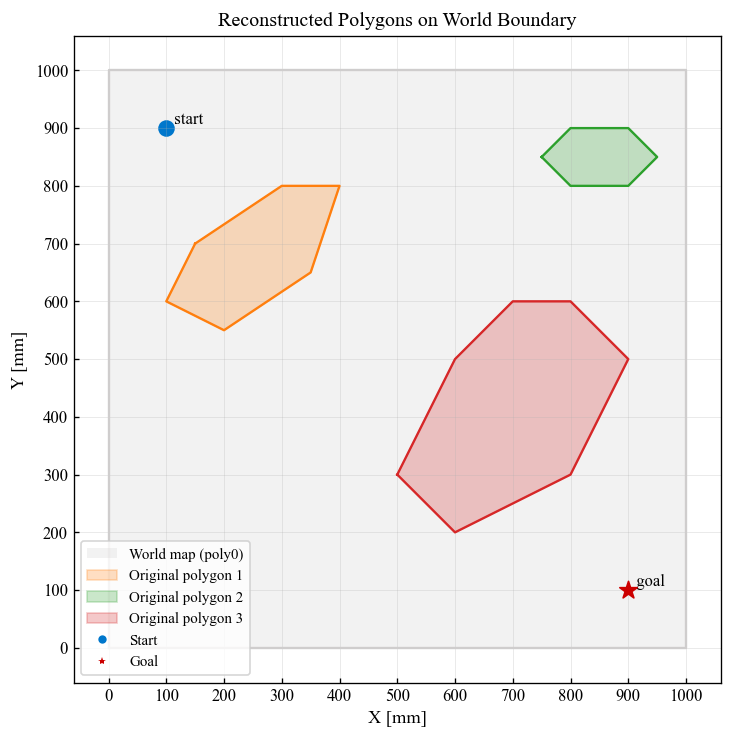

In [7]:
# Number of polygons
num_polygons = len(polygons_ccw)

# Get final list of polygon colors
polygon_colors = get_polygon_colors(num_polygons, POLYGON_BASE_COLORS)

# Convert dict keys to a list so we have stable ordering
polygon_ids = list(polygons_ccw.keys())

# Bounds for grid / axes (use all polygon vertices)
all_points = []
for ring in polygons_ccw.values():
    all_points.extend(ring)

# Also include start/goal in bounds
all_points.append(special_points["start"])
all_points.append(special_points["goal"])

bx, by = zip(*all_points)
xmin, xmax = min(bx), max(bx)
ymin, ymax = min(by), max(by)
pad = 0.06 * max(xmax - xmin, ymax - ymin)

# Plot graph
fig, ax = plt.subplots(figsize=(7, 7))

# Plot polygons with assigned colors ---
for i, pid in enumerate(polygon_ids):
    ring = polygons_ccw[pid]
    px, py = zip(*ring)
    col = polygon_colors[i]

    ax.fill(px, py, color=col, alpha=0.25)
    ax.plot(list(px)+[px[0]], 
            list(py)+[py[0]], 
            color=col, 
            linewidth=1.4
            )


# Extract start + goal
sx, sy = special_points["start"]
gx, gy = special_points["goal"]

# Plot start (circle) and goal (star)
ax.scatter([sx], [sy], s=80, color=COLOR_START, marker="o")
ax.text(sx, sy, "  start", va="bottom", ha="left", fontsize=10)

ax.scatter([gx], [gy], s=120, color=COLOR_GOAL, marker="*", zorder=5)
ax.text(gx, gy, "  goal", va="bottom", ha="left", fontsize=10)

# Light grid
ax.set_xticks(np.arange(xmin, xmax + 1, 100))
ax.set_yticks(np.arange(ymin, ymax + 1, 100))
ax.grid(True, linewidth=0.5, alpha=0.3)

# Equal aspect ratio
ax.set_aspect("equal", adjustable="box")

# Add some padding around
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

# Labels and title
ax.set_xlabel("X [mm]")
ax.set_ylabel("Y [mm]")
ax.set_title("Reconstructed Polygons on World Boundary")

# --- 7. Custom legend -------------------------------------------------
# polygon_colors[0] = world boundary (grey from your POLYGON_BASE_COLORS)
# polygon_colors[1] = inflated polygon 1 (orange)
# polygon_colors[2] = inflated polygon 2 (green)
# polygon_colors[3] = inflated polygon 3 (red)

legend_elements = [
    # World map (poly0)
    Patch(facecolor=polygon_colors[0], edgecolor="none", alpha=0.25,
          label="World map (poly0)"),
    # Original polygons
    Patch(facecolor=polygon_colors[1], edgecolor=polygon_colors[1], alpha=0.25,
          label="Original polygon 1"),
    Patch(facecolor=polygon_colors[2], edgecolor=polygon_colors[2], alpha=0.25,
          label="Original polygon 2"),
    Patch(facecolor=polygon_colors[3], edgecolor=polygon_colors[3], alpha=0.25,
          label="Original polygon 3"),
    # Start / goal
    Line2D([], [], marker="o", linestyle="None", markerfacecolor=COLOR_START,
           markeredgecolor="none", label="Start"),
    Line2D([], [], marker="*", linestyle="None", markerfacecolor=COLOR_GOAL,
           markeredgecolor="none", label="Goal"),
]

ax.legend(handles=legend_elements, loc="lower left", frameon=True)

plt.show()

In [8]:
def build_nodes_from_polygons(polygons_ccw, special_points):
    """
    polygons_ccw: dict pid -> [(x,y), ...], including 'poly0'
    special_points: {'start': (sx,sy), 'goal': (gx,gy)}

    Returns:
        node_coords: list of (x,y)
        node_labels: list of labels for each node (str)
        start_idx: index of start node
        goal_idx: index of goal node
    """
    node_coords = []
    node_labels = []

    # 1) obstacle vertices (all polygons except poly0)
    for pid, ring in polygons_ccw.items():
        if pid == "poly0":
            continue  # skip outer boundary as nodes

        for k, (x, y) in enumerate(ring):
            node_coords.append((float(x), float(y)))
            node_labels.append(f"{pid}_{k}")  # simple label; can change later

    # 2) start node
    sx, sy = special_points["start"]
    start_idx = len(node_coords)
    node_coords.append((float(sx), float(sy)))
    node_labels.append("start")

    # 3) goal node
    gx, gy = special_points["goal"]
    goal_idx = len(node_coords)
    node_coords.append((float(gx), float(gy)))
    node_labels.append("goal")

    return node_coords, node_labels, start_idx, goal_idx 




In [9]:
node_coords, node_labels, start_idx, goal_idx = build_nodes_from_polygons(polygons_ccw, special_points)
N = len(node_coords)
print("Total nodes:", N)
print("start_idx:", start_idx, "goal_idx:", goal_idx)

Total nodes: 21
start_idx: 19 goal_idx: 20


In [10]:
# Outer boundary polygon (world)
world_poly = Polygon(polygons_ccw["poly0"])

# Obstacles: all polygons except poly0
obstacle_polys = []
for pid, ring in polygons_ccw.items():
    if pid == "poly0":
        continue
    obstacle_polys.append(Polygon(ring))

High-level rule (your chosen policy):

Segment must stay inside the outer boundary.

Segment must not cross the interior of any obstacle.

It’s OK if it just touches polygons at endpoints or vertices.

In [11]:
def segment_visible(p, q, world_poly, obstacle_polys):
    """
    Check if segment p–q is valid:
      - stays within world_poly
      - does not cross obstacle interiors
      - touching at vertices/edges is allowed
    """
    seg = LineString([p, q])

    # 1) Stay inside/ on the boundary of the world
    if not (seg.within(world_poly) or seg.touches(world_poly)):
        return False

    # 2) Check obstacles
    for poly in obstacle_polys:
        # if segment properly crosses interior: not allowed
        if seg.crosses(poly):
            return False
        # if entire segment lies inside obstacle: not allowed
        if seg.within(poly) or poly.contains(seg):
            return False
        # seg.touches(poly): allowed (your chosen policy)

    return True


def euclidean_distance(p, q):
    dx = p[0] - q[0]
    dy = p[1] - q[1]
    return math.hypot(dx, dy)


def build_neighbors(node_coords, world_poly, obstacle_polys):
    """
    Build visibility graph adjacency list.

    node_coords: list of (x,y)
    world_poly: shapely Polygon for outer boundary
    obstacle_polys: list of shapely Polygons (inflated or original)

    Returns:
        neighbors: list-of-lists adjacency: neighbors[i] = [(j, weight_ij), ...]
    """
    N = len(node_coords)
    neighbors = [[] for _ in range(N)]

    for i in range(N):
        p = node_coords[i]
        for j in range(i + 1, N):
            q = node_coords[j]

            if segment_visible(p, q, world_poly, obstacle_polys):
                d = euclidean_distance(p, q)
                neighbors[i].append((j, d))
                neighbors[j].append((i, d))

    return neighbors


In [12]:
# --- ORIGINAL WORLD ---
polygons_ccw_raw = polygons_ccw        # just renaming for clarity

# shapely polygons for original world
world_poly_raw = Polygon(polygons_ccw_raw["poly0"])
obstacle_polys_raw = [
    Polygon(ring) for pid, ring in polygons_ccw_raw.items() if pid != "poly0"
]

# nodes for original world
node_coords_raw, node_labels_raw, start_idx_raw, goal_idx_raw = \
    build_nodes_from_polygons(polygons_ccw_raw, special_points)

# neighbors for original world
neighbors_raw = build_neighbors(node_coords_raw, world_poly_raw, obstacle_polys_raw)

node_coords = node_coords_raw
node_labels = node_labels_raw
neighbors   = neighbors_raw

#print("=== LIST OF NODES ===")
#for i, (coord, label) in enumerate(zip(node_coords, node_labels)):
#    print(f"Node {i:2d} | label={label:8s} | coord={coord}")

print("\n=== NEIGHBOR COUNTS ===")
for i, nbrs in enumerate(neighbors):
    print(f"Node {i:2d} ({node_labels[i]:8s}) has {len(nbrs)} neighbors")

#print("\n=== NEIGHBOR DETAILS ===")
#for i, nbrs in enumerate(neighbors):
#    print(f"\nNode {i} ({node_labels[i]}) neighbors:")
#    for (j, dist_ij) in nbrs:
#        print(f"   → {j} ({node_labels[j]}), distance = {dist_ij:.2f}")


=== NEIGHBOR COUNTS ===
Node  0 (poly1_0 ) has 3 neighbors
Node  1 (poly1_1 ) has 5 neighbors
Node  2 (poly1_2 ) has 10 neighbors
Node  3 (poly1_3 ) has 10 neighbors
Node  4 (poly1_4 ) has 11 neighbors
Node  5 (poly1_5 ) has 7 neighbors
Node  6 (poly2_0 ) has 12 neighbors
Node  7 (poly2_1 ) has 11 neighbors
Node  8 (poly2_2 ) has 11 neighbors
Node  9 (poly2_3 ) has 7 neighbors
Node 10 (poly2_4 ) has 3 neighbors
Node 11 (poly2_5 ) has 7 neighbors
Node 12 (poly3_0 ) has 7 neighbors
Node 13 (poly3_1 ) has 5 neighbors
Node 14 (poly3_2 ) has 3 neighbors
Node 15 (poly3_3 ) has 7 neighbors
Node 16 (poly3_4 ) has 8 neighbors
Node 17 (poly3_5 ) has 9 neighbors
Node 18 (poly3_6 ) has 9 neighbors
Node 19 (start   ) has 8 neighbors
Node 20 (goal    ) has 5 neighbors


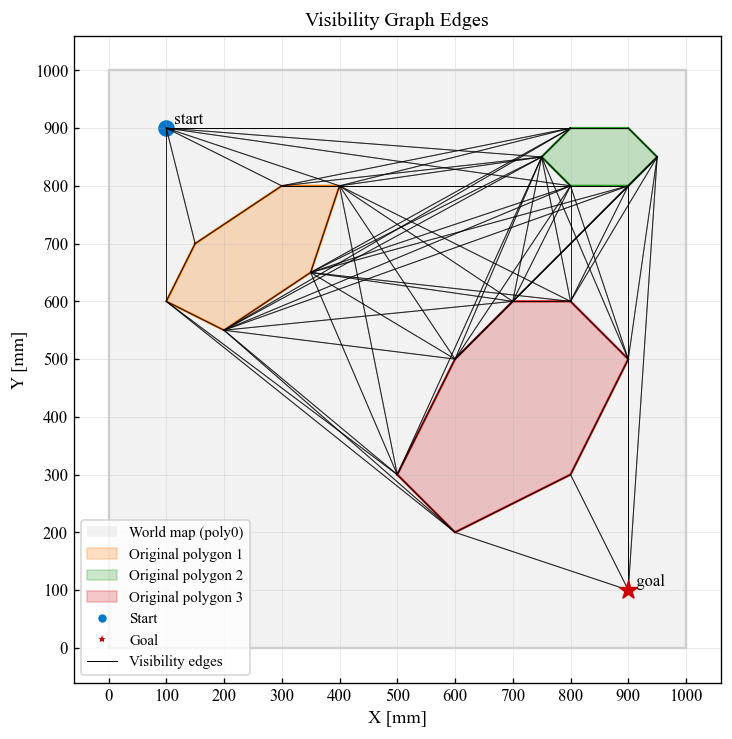

In [13]:
# ===============================================================
# PLOT: Polygons + Start/Goal + All Visibility Edges
# ===============================================================

fig, ax = plt.subplots()

# --- 1. Plot polygons (same as before) ---
for i, pid in enumerate(polygon_ids):
    ring = polygons_ccw[pid]
    px, py = zip(*ring)
    col = polygon_colors[i]

    ax.fill(px, py, color=col, alpha=0.25)
    ax.plot(list(px) + [px[0]],
            list(py) + [py[0]],
            color=col,
            linewidth=1.4)

# --- 2. Plot all visibility edges (thin lines) ---
for i, nbr_list in enumerate(neighbors):
    x1, y1 = node_coords[i]
    for j, dist_ij in nbr_list:
        x2, y2 = node_coords[j]

        # draw thin grey visibility edge
        ax.plot([x1, x2], [y1, y2],
                color="black",
                linewidth=0.6,
                alpha=0.6)

# --- 3. Plot start and goal ---
sx, sy = special_points["start"]
gx, gy = special_points["goal"]

ax.scatter([sx], [sy], s=80, color=COLOR_START, marker="o")
ax.text(sx, sy, "  start", va="bottom", ha="left", fontsize=10)

ax.scatter([gx], [gy], s=120, color=COLOR_GOAL, marker="*", zorder=5)
ax.text(gx, gy, "  goal", va="bottom", ha="left", fontsize=10)

# --- 4. Grid, limits, labels ---
ax.set_xticks(np.arange(xmin, xmax + 1, 100))
ax.set_yticks(np.arange(ymin, ymax + 1, 100))
ax.grid(True, linewidth=0.5, alpha=0.3)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

ax.set_xlabel("X [mm]")
ax.set_ylabel("Y [mm]")
ax.set_title("Visibility Graph Edges")

# --- 7. Custom legend -------------------------------------------------
# polygon_colors[0] = world boundary (grey from your POLYGON_BASE_COLORS)
# polygon_colors[1] = inflated polygon 1 (orange)
# polygon_colors[2] = inflated polygon 2 (green)
# polygon_colors[3] = inflated polygon 3 (red)

legend_elements = [
    # World map (poly0)
    Patch(facecolor=polygon_colors[0], edgecolor="none", alpha=0.25,
          label="World map (poly0)"),
    # Original polygons
    Patch(facecolor=polygon_colors[1], edgecolor=polygon_colors[1], alpha=0.25,
          label="Original polygon 1"),
    Patch(facecolor=polygon_colors[2], edgecolor=polygon_colors[2], alpha=0.25,
          label="Original polygon 2"),
    Patch(facecolor=polygon_colors[3], edgecolor=polygon_colors[3], alpha=0.25,
          label="Original polygon 3"),
    # Start / goal
    Line2D([], [], marker="o", linestyle="None", markerfacecolor=COLOR_START,
           markeredgecolor="none", label="Start"),
    Line2D([], [], marker="*", linestyle="None", markerfacecolor=COLOR_GOAL,
           markeredgecolor="none", label="Goal"),

# Paths / edges
    Line2D([], [], color="black", linewidth=0.6, label="Visibility edges"),
]

ax.legend(handles=legend_elements, loc="lower left", frameon=True)

plt.show()


In [14]:
def inflate_polygons(polygons_ccw, epsilon, shrink_outer=True):
    """
    polygons_ccw: dict pid -> [(x,y), ...]  (already CCW for the original shapes)
    epsilon: inflation radius (cm)
    shrink_outer: (currently ignored) outer boundary poly0 is kept unchanged
    
    returns: new dict pid -> [(x,y), ...] for inflated/shrunk polygons,
             each ring forced to CCW using ensure_ccw().
    """
    inflated = {}

    for pid, ring in polygons_ccw.items():
        poly = Polygon(ring)

        if pid == "poly0":
            # ❗ Do NOT inflate or shrink outer boundary: keep as-is
            ring_ccw = ensure_ccw(ring)
            inflated[pid] = ring_ccw
            continue

        # 1) Inflate obstacles (all polygons except poly0)
        buffered = poly.buffer(epsilon, join_style=2, resolution=1)

        # 2) Handle possible MultiPolygon (rare for nice convex shapes)
        if buffered.geom_type == "MultiPolygon":
            parts = list(buffered.geoms)
            buffered = max(parts, key=lambda p: p.area)

        # 3) Extract exterior coordinates
        xs, ys = buffered.exterior.coords.xy
        ring_raw = list(zip(xs, ys))[:-1]  # drop last point == first point

        # 4) Enforce CCW using your own helper
        ring_ccw = ensure_ccw(ring_raw)

        inflated[pid] = ring_ccw

    return inflated


In [15]:
#Recalculate new nodes
EPSILON_CM = 2.0  # cm, or whatever you want
EPSILON = EPSILON_CM * UNIT_SCALE  # now 20.0 mm

polygons_ccw_eps = inflate_polygons(polygons_ccw_raw, EPSILON, shrink_outer=True)

# shapely polygons for inflated world
world_poly_eps = Polygon(polygons_ccw_eps["poly0"])
obstacle_polys_eps = [
    Polygon(ring) for pid, ring in polygons_ccw_eps.items() if pid != "poly0"
]

# nodes for inflated world
node_coords_eps, node_labels_eps, start_idx_eps, goal_idx_eps = \
    build_nodes_from_polygons(polygons_ccw_eps, special_points)

# neighbors for inflated world
neighbors_eps = build_neighbors(node_coords_eps, world_poly_eps, obstacle_polys_eps)

node_coords = node_coords_eps
node_labels = node_labels_eps
neighbors   = neighbors_eps

#print("=== LIST OF NODES ===")
#for i, (coord, label) in enumerate(zip(node_coords, node_labels)):
#    print(f"Node {i:2d} | label={label:8s} | coord={coord}")

print("\n=== NEIGHBOR COUNTS ===")
for i, nbrs in enumerate(neighbors):
    print(f"Node {i:2d} ({node_labels[i]:8s}) has {len(nbrs)} neighbors")

#print("\n=== NEIGHBOR DETAILS ===")
#for i, nbrs in enumerate(neighbors):
#    print(f"\nNode {i} ({node_labels[i]}) neighbors:")
#    for (j, dist_ij) in nbrs:
#        print(f"   → {j} ({node_labels[j]}), distance = {dist_ij:.2f}")








=== NEIGHBOR COUNTS ===
Node  0 (poly1_0 ) has 5 neighbors
Node  1 (poly1_1 ) has 10 neighbors
Node  2 (poly1_2 ) has 10 neighbors
Node  3 (poly1_3 ) has 10 neighbors
Node  4 (poly1_4 ) has 5 neighbors
Node  5 (poly1_5 ) has 3 neighbors
Node  6 (poly2_0 ) has 10 neighbors
Node  7 (poly2_1 ) has 7 neighbors
Node  8 (poly2_2 ) has 5 neighbors
Node  9 (poly2_3 ) has 2 neighbors
Node 10 (poly2_4 ) has 7 neighbors
Node 11 (poly2_5 ) has 12 neighbors
Node 12 (poly3_0 ) has 5 neighbors
Node 13 (poly3_1 ) has 3 neighbors
Node 14 (poly3_2 ) has 7 neighbors
Node 15 (poly3_3 ) has 8 neighbors
Node 16 (poly3_4 ) has 8 neighbors
Node 17 (poly3_5 ) has 7 neighbors
Node 18 (poly3_6 ) has 7 neighbors
Node 19 (start   ) has 7 neighbors
Node 20 (goal    ) has 4 neighbors


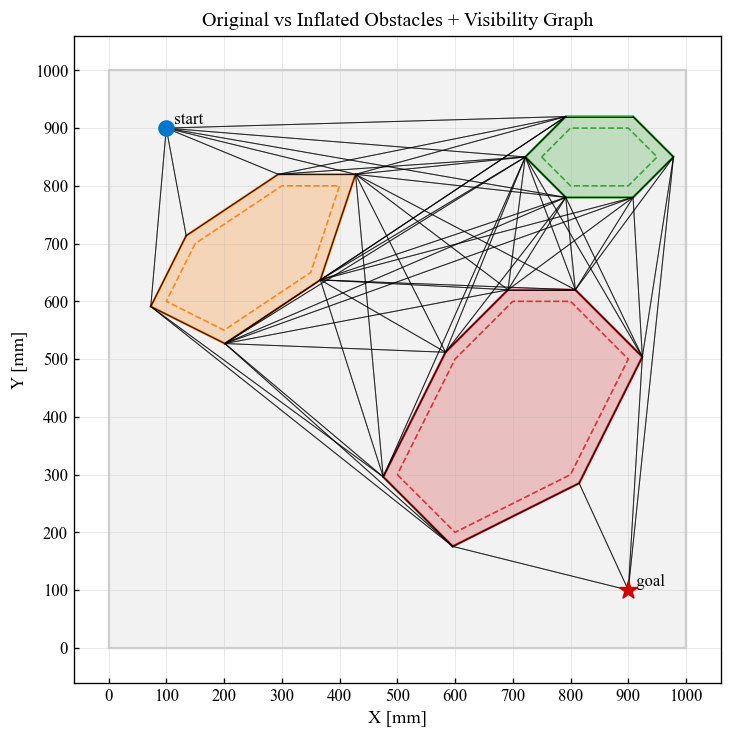

In [16]:
# ===============================================================
# PLOT: Original vs Inflated Polygons + Start/Goal + Visibility Edges
# ===============================================================

fig, ax = plt.subplots()

# --- 0. Prepare ids & colors (based on inflated polygons) ---
polygon_ids = list(polygons_ccw_eps.keys())
num_polygons = len(polygon_ids)
polygon_colors = get_polygon_colors(num_polygons, POLYGON_BASE_COLORS)

# --- 1. Bounds for grid / axes (use inflated polygons + start/goal) ---
all_points = []
for ring in polygons_ccw_eps.values():
    all_points.extend(ring)

all_points.append(special_points["start"])
all_points.append(special_points["goal"])

bx, by = zip(*all_points)
xmin, xmax = min(bx), max(bx)
ymin, ymax = min(by), max(by)
pad = 0.06 * max(xmax - xmin, ymax - ymin)

# --- 2. Plot *inflated* polygons (filled, solid) ---
for i, pid in enumerate(polygon_ids):
    ring = polygons_ccw_eps[pid]
    px, py = zip(*ring)
    col = polygon_colors[i]

    # filled inflated obstacle
    ax.fill(px, py, color=col, alpha=0.25)
    ax.plot(list(px) + [px[0]],
            list(py) + [py[0]],
            color=col,
            linewidth=1.4)

# --- 3. Plot *original* polygons as dashed outlines on top ---
for i, pid in enumerate(polygon_ids):
    if pid not in polygons_ccw_raw:
        continue  # just in case

    ring_raw = polygons_ccw_raw[pid]
    ox, oy = zip(*ring_raw)
    col = polygon_colors[i]

    ax.plot(list(ox) + [ox[0]],
            list(oy) + [oy[0]],
            color=col,
            linewidth=1.0,
            linestyle="--",
            alpha=0.9,
            label="original" if i == 0 else None)

# --- 4. Plot all visibility edges (thin lines, built from inflated graph) ---
for i, nbr_list in enumerate(neighbors):
    x1, y1 = node_coords[i]
    for j, dist_ij in nbr_list:
        x2, y2 = node_coords[j]

        ax.plot([x1, x2], [y1, y2],
                color="black",
                linewidth=0.6,
                alpha=0.6)

# --- 5. Plot start and goal ---
sx, sy = special_points["start"]
gx, gy = special_points["goal"]

ax.scatter([sx], [sy], s=80, color=COLOR_START, marker="o", zorder=5)
ax.text(sx, sy, "  start", va="bottom", ha="left", fontsize=10)

ax.scatter([gx], [gy], s=120, color=COLOR_GOAL, marker="*", zorder=6)
ax.text(gx, gy, "  goal", va="bottom", ha="left", fontsize=10)

# --- 6. Grid, limits, labels ---
ax.set_xticks(np.arange(xmin, xmax + 1, 100))
ax.set_yticks(np.arange(ymin, ymax + 1, 100))
ax.grid(True, linewidth=0.5, alpha=0.3)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

ax.set_xlabel("X [mm]")
ax.set_ylabel("Y [mm]")
ax.set_title("Original vs Inflated Obstacles + Visibility Graph")

plt.show()


In [17]:
def heuristic(i, goal_idx, node_coords):
    """Euclidean distance from node i to goal."""
    x1, y1 = node_coords[i]
    x2, y2 = node_coords[goal_idx]
    return math.hypot(x1 - x2, y1 - y2)

def astar(neighbors, node_coords, start_idx, goal_idx):
    """
    Run A* on a visibility graph.

    neighbors: adjacency list, neighbors[i] = [(j, weight_ij), ...]
    node_coords: list of (x, y) for each node index
    start_idx, goal_idx: integer node indices

    Returns:
        path_indices: [start_idx, ..., goal_idx] or None if no path
        explored: set of visited node indices (for debugging/plotting)
        operation_count: how many neighbor relaxations we did
    """
    # Cost from start to each node (g-cost)
    g_cost = {start_idx: 0.0}

    # To reconstruct path: child -> parent
    came_from = {}

    # Explored set (closed set)
    explored = set()

    # Priority queue: (f_cost, g_cost, node_idx)
    open_set = []
    start_h = heuristic(start_idx, goal_idx, node_coords)
    heapq.heappush(open_set, (start_h, 0.0, start_idx))

    operation_count = 0

    while open_set:
        f_curr, g_curr, current = heapq.heappop(open_set)

        # If we've already processed this node with a better g, skip
        if current in explored:
            continue

        explored.add(current)

        # Goal check
        if current == goal_idx:
            break

        # Relax all neighbors
        for neighbor, weight in neighbors[current]:
            tentative_g = g_curr + weight

            # If this path to neighbor is better, record it
            if (neighbor not in g_cost) or (tentative_g < g_cost[neighbor]):
                g_cost[neighbor] = tentative_g
                came_from[neighbor] = current
                h = heuristic(neighbor, goal_idx, node_coords)
                f = tentative_g + h
                heapq.heappush(open_set, (f, tentative_g, neighbor))
                operation_count += 1

    # Reconstruct path if goal reached
    if goal_idx not in came_from and start_idx != goal_idx:
        # No path found
        return None, explored, operation_count

    path_indices = [goal_idx]
    current = goal_idx
    while current != start_idx:
        current = came_from[current]
        path_indices.append(current)
    path_indices.reverse()

    return path_indices, explored, operation_count

In [18]:
path_indices, explored_nodes, op_count = astar(
    neighbors, node_coords, start_idx, goal_idx
)

if path_indices is None:
    print("No path found.")
else:
    print("A* operation count:", op_count)
    print("Number of explored nodes:", len(explored_nodes))
    print("Path node indices:", path_indices)

    # If you have node_labels:
    print("Path labels:", [node_labels[i] for i in path_indices])
    print("Path coordinates:", [node_coords[i] for i in path_indices])

A* operation count: 19
Number of explored nodes: 12
Path node indices: [19, 0, 12, 20]
Path labels: ['start', 'poly1_0', 'poly3_0', 'goal']
Path coordinates: [(100.0, 900.0), (73.16718427000252, 591.0557280900009), (596.0509390183573, 175.66478973418074), (900.0, 100.0)]


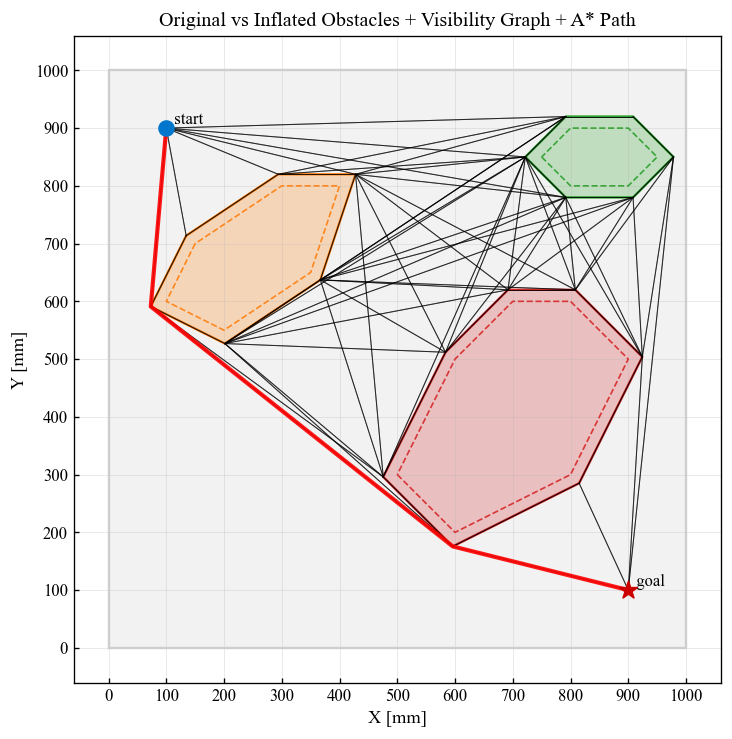

In [19]:
# ===============================================================
# PLOT: Original vs Inflated Polygons + Start/Goal + Visibility Edges + PATH
# ===============================================================

fig, ax = plt.subplots()

# --- 0. Prepare ids & colors (based on inflated polygons) ---
polygon_ids = list(polygons_ccw_eps.keys())
num_polygons = len(polygon_ids)
polygon_colors = get_polygon_colors(num_polygons, POLYGON_BASE_COLORS)

# --- 1. Bounds for grid / axes (use inflated polygons + start/goal) ---
all_points = []
for ring in polygons_ccw_eps.values():
    all_points.extend(ring)

all_points.append(special_points["start"])
all_points.append(special_points["goal"])

bx, by = zip(*all_points)
xmin, xmax = min(bx), max(bx)
ymin, ymax = min(by), max(by)
pad = 0.06 * max(xmax - xmin, ymax - ymin)

# --- 2. Plot *inflated* polygons (filled, solid) ---
for i, pid in enumerate(polygon_ids):
    ring = polygons_ccw_eps[pid]
    px, py = zip(*ring)
    col = polygon_colors[i]

    ax.fill(px, py, color=col, alpha=0.25)
    ax.plot(list(px) + [px[0]],
            list(py) + [py[0]],
            color=col,
            linewidth=1.4)

# --- 3. Plot *original* polygons as dashed outlines ---
for i, pid in enumerate(polygon_ids):
    if pid not in polygons_ccw_raw:
        continue

    ring_raw = polygons_ccw_raw[pid]
    ox, oy = zip(*ring_raw)
    col = polygon_colors[i]

    ax.plot(list(ox) + [ox[0]],
            list(oy) + [oy[0]],
            color=col,
            linewidth=1.0,
            linestyle="--",
            alpha=0.9)

# --- 4. Plot all visibility edges ---
for i, nbr_list in enumerate(neighbors):
    x1, y1 = node_coords[i]
    for j, dist_ij in nbr_list:
        x2, y2 = node_coords[j]
        ax.plot([x1, x2], [y1, y2],
                color="black",
                linewidth=0.6,
                alpha=0.6)

# --- 4b. OVERLAY A* OPTIMAL PATH (THICK RED) ---
if path_indices is not None:
    path_xy = [node_coords[i] for i in path_indices]
    px_path = [p[0] for p in path_xy]
    py_path = [p[1] for p in path_xy]

    ax.plot(px_path, py_path,
            color="red",
            linewidth=2.5,
            alpha=0.9,
            zorder=10,
            label="A* optimal path")

# --- 5. Plot start and goal ---
sx, sy = special_points["start"]
gx, gy = special_points["goal"]

ax.scatter([sx], [sy], s=80, color=COLOR_START, marker="o", zorder=15)
ax.text(sx, sy, "  start", va="bottom", ha="left", fontsize=10)

ax.scatter([gx], [gy], s=120, color=COLOR_GOAL, marker="*", zorder=15)
ax.text(gx, gy, "  goal", va="bottom", ha="left", fontsize=10)

# --- 6. Grid, limits, labels ---
ax.set_xticks(np.arange(xmin, xmax + 1, 100))
ax.set_yticks(np.arange(ymin, ymax + 1, 100))
ax.grid(True, linewidth=0.5, alpha=0.3)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

ax.set_xlabel("X [mm]")
ax.set_ylabel("Y [mm]")
ax.set_title("Original vs Inflated Obstacles + Visibility Graph + A* Path")

plt.show()


In [20]:
# Load with correct delimiter
odom_df = pd.read_csv("CSV_Data/odometry2.csv", sep=";")

# Clean column names
odom_df.columns = [c.strip().lower() for c in odom_df.columns]

# Rename x,y columns (they contain units in the name)
odom_df = odom_df.rename(columns={
    "x / mm": "x",
    "y / mm": "y",
    "theta / rad": "theta",
    "v / mm/s": "v",
    "omega rad/s": "omega"
})

# Extract trajectory
traj_x = odom_df["x"].astype(float).tolist()
traj_y = odom_df["y"].astype(float).tolist()

print("Loaded trajectory:", len(traj_x), "points")
print("First x,y:", list(zip(traj_x[:5], traj_y[:5])))

Loaded trajectory: 49 points
First x,y: [(100.0, 900.0), (99.466, 900.167), (99.681, 899.828), (99.694, 899.628), (99.697, 899.675)]


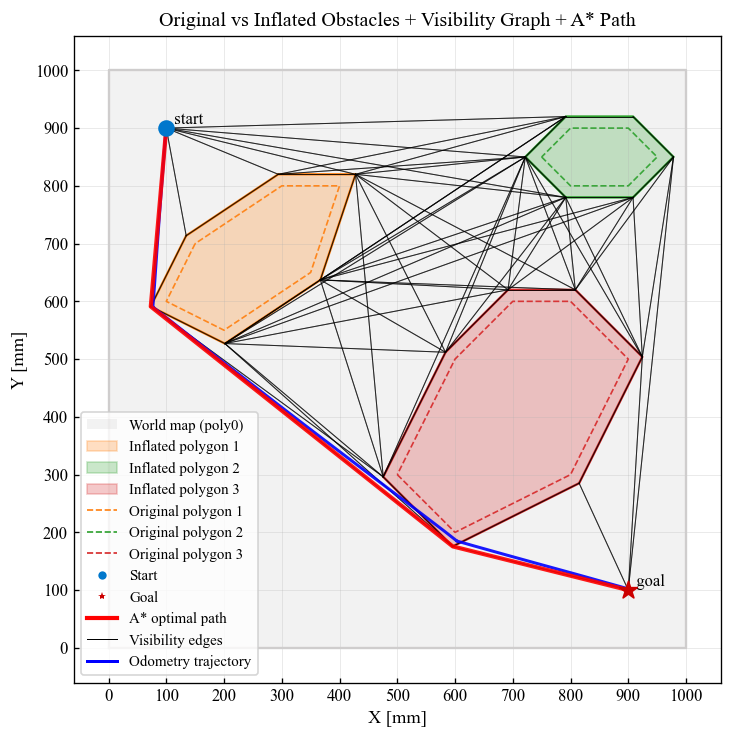

In [21]:
# ===============================================================
# PLOT: Original vs Inflated Polygons + Start/Goal + Visibility Edges + PATH
# ===============================================================

fig, ax = plt.subplots()

# --- 0. Prepare ids & colors (based on inflated polygons) ---
polygon_ids = list(polygons_ccw_eps.keys())
num_polygons = len(polygon_ids)
polygon_colors = get_polygon_colors(num_polygons, POLYGON_BASE_COLORS)

# --- 1. Bounds for grid / axes (use inflated polygons + start/goal) ---
all_points = []
for ring in polygons_ccw_eps.values():
    all_points.extend(ring)

all_points.append(special_points["start"])
all_points.append(special_points["goal"])

bx, by = zip(*all_points)
xmin, xmax = min(bx), max(bx)
ymin, ymax = min(by), max(by)
pad = 0.06 * max(xmax - xmin, ymax - ymin)

# --- 2. Plot *inflated* polygons (filled, solid) ---
for i, pid in enumerate(polygon_ids):
    ring = polygons_ccw_eps[pid]
    px, py = zip(*ring)
    col = polygon_colors[i]

    ax.fill(px, py, color=col, alpha=0.25)
    ax.plot(list(px) + [px[0]],
            list(py) + [py[0]],
            color=col,
            linewidth=1.4)

# --- 3. Plot *original* polygons as dashed outlines ---
for i, pid in enumerate(polygon_ids):
    if pid not in polygons_ccw_raw:
        continue

    ring_raw = polygons_ccw_raw[pid]
    ox, oy = zip(*ring_raw)
    col = polygon_colors[i]

    ax.plot(list(ox) + [ox[0]],
            list(oy) + [oy[0]],
            color=col,
            linewidth=1.0,
            linestyle="--",
            alpha=0.9)

# --- 4. Plot all visibility edges ---
for i, nbr_list in enumerate(neighbors):
    x1, y1 = node_coords[i]
    for j, dist_ij in nbr_list:
        x2, y2 = node_coords[j]
        ax.plot([x1, x2], [y1, y2],
                color="black",
                linewidth=0.6,
                alpha=0.6)

# --- 4b. OVERLAY A* OPTIMAL PATH (THICK RED) ---
if path_indices is not None:
    path_xy = [node_coords[i] for i in path_indices]
    px_path = [p[0] for p in path_xy]
    py_path = [p[1] for p in path_xy]

    ax.plot(px_path, py_path,
            color="red",
            linewidth=2.5,
            alpha=0.9,
            zorder=10,
            label="A* optimal path")

# --- 4c. OVERLAY REAL ROBOT TRAJECTORY (BLUE LINE) ---
if len(traj_x) > 1:
    ax.plot(traj_x, traj_y,
            color="blue",
            linewidth=1.8,
            alpha=0.9,
            zorder=9,
            label="Measured trajectory")

# --- 5. Plot start and goal ---
sx, sy = special_points["start"]
gx, gy = special_points["goal"]

ax.scatter([sx], [sy], s=80, color=COLOR_START, marker="o", zorder=15)
ax.text(sx, sy, "  start", va="bottom", ha="left", fontsize=10)

ax.scatter([gx], [gy], s=120, color=COLOR_GOAL, marker="*", zorder=15)
ax.text(gx, gy, "  goal", va="bottom", ha="left", fontsize=10)

# --- 6. Grid, limits, labels ---
ax.set_xticks(np.arange(xmin, xmax + 1, 100))
ax.set_yticks(np.arange(ymin, ymax + 1, 100))
ax.grid(True, linewidth=0.5, alpha=0.3)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

ax.set_xlabel("X [mm]")
ax.set_ylabel("Y [mm]")
ax.set_title("Original vs Inflated Obstacles + Visibility Graph + A* Path")

# --- 7. Custom legend -------------------------------------------------
# polygon_colors[0] = world boundary (grey from your POLYGON_BASE_COLORS)
# polygon_colors[1] = inflated polygon 1 (orange)
# polygon_colors[2] = inflated polygon 2 (green)
# polygon_colors[3] = inflated polygon 3 (red)

legend_elements = [
    # World map (poly0)
    Patch(facecolor=polygon_colors[0], edgecolor="none", alpha=0.25,
          label="World map (poly0)"),
    # Inflated polygons (solid)
    Patch(facecolor=polygon_colors[1], edgecolor=polygon_colors[1], alpha=0.25,
          label="Inflated polygon 1"),
    Patch(facecolor=polygon_colors[2], edgecolor=polygon_colors[2], alpha=0.25,
          label="Inflated polygon 2"),
    Patch(facecolor=polygon_colors[3], edgecolor=polygon_colors[3], alpha=0.25,
          label="Inflated polygon 3"),
    # Original polygons (dashed outlines)
    Line2D([], [], linestyle="--", color=polygon_colors[1],
           label="Original polygon 1"),
    Line2D([], [], linestyle="--", color=polygon_colors[2],
           label="Original polygon 2"),
    Line2D([], [], linestyle="--", color=polygon_colors[3],
           label="Original polygon 3"),
    # Start / goal
    Line2D([], [], marker="o", linestyle="None", markerfacecolor=COLOR_START,
           markeredgecolor="none", label="Start"),
    Line2D([], [], marker="*", linestyle="None", markerfacecolor=COLOR_GOAL,
           markeredgecolor="none", label="Goal"),
    # Paths / edges
    Line2D([], [], color="red", linewidth=2.5, label="A* optimal path"),
    Line2D([], [], color="black", linewidth=0.6, label="Visibility edges"),
    Line2D([], [], color="blue", linewidth=1.8, label="Odometry trajectory"),
]

ax.legend(handles=legend_elements, loc="lower left", frameon=True)

plt.show()

